In [1]:
import pandas as pd
df = pd.read_csv("cloud_usage_cost_data.csv")

In [2]:
df.head(), df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   vm_size           1000 non-null   object 
 1   cpu_usage_avg     1000 non-null   float64
 2   memory_usage_avg  1000 non-null   float64
 3   disk_io           1000 non-null   float64
 4   network_in        1000 non-null   float64
 5   network_out       1000 non-null   float64
 6   uptime_hours      1000 non-null   float64
 7   monthly_cost      1000 non-null   float64
dtypes: float64(7), object(1)
memory usage: 62.6+ KB


(        vm_size  cpu_usage_avg  memory_usage_avg     disk_io  network_in  \
 0  Standard_D4s      85.810716         72.219485  319.396318   55.245406   
 1  Standard_E4s      56.094776         70.186169   59.263022  291.273857   
 2  Standard_D4s      20.589383         35.860591  286.140394  135.264055   
 3  Standard_B2s       8.966581         92.769219  154.747103   36.275866   
 4  Standard_D4s      55.355238         13.948285  323.395183   59.451996   
 
    network_out  uptime_hours  monthly_cost  
 0    55.238411    136.011840        318.79  
 1   251.408366    231.650249        402.66  
 2    94.456451    479.348795        354.20  
 3   189.331943    337.126435        210.04  
 4    28.864962    688.309033        394.53  ,
 None,
        cpu_usage_avg  memory_usage_avg      disk_io   network_in  network_out  \
 count    1000.000000       1000.000000  1000.000000  1000.000000  1000.000000   
 mean       47.334984         51.999904   273.212868   152.913310   155.200468   
 std  

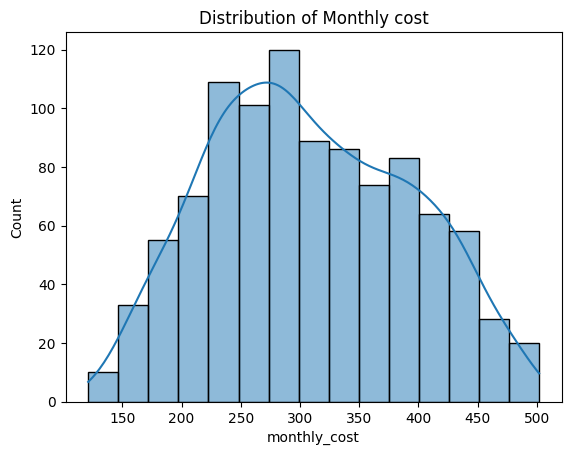

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["monthly_cost"], kde=True)
plt.title("Distribution of Monthly cost")
plt.show()
#right skewed

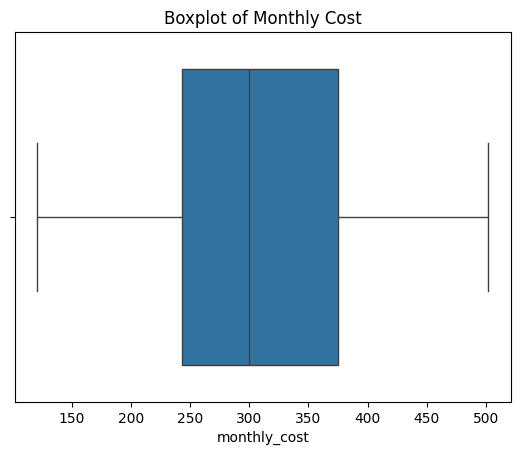

In [4]:
sns.boxplot(x=df["monthly_cost"])
plt.title("Boxplot of Monthly Cost")
plt.show()

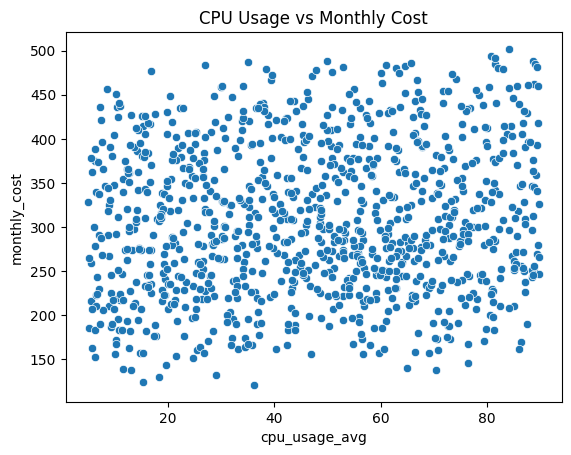

In [5]:
sns.scatterplot(
    x="cpu_usage_avg",
    y="monthly_cost",
    data=df
)
plt.title("CPU Usage vs Monthly Cost")
plt.show()


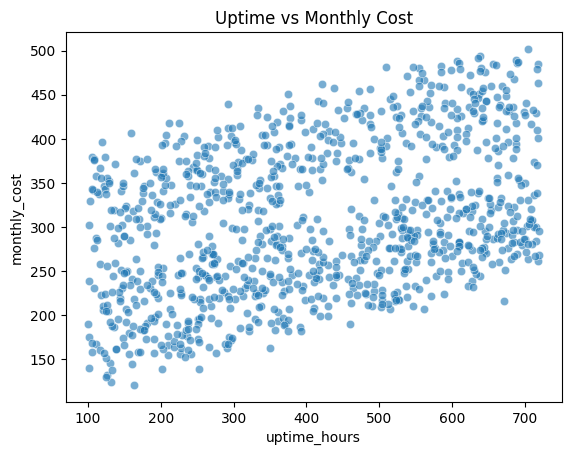

In [6]:
sns.scatterplot(
    x="uptime_hours",
    y="monthly_cost",
    data=df,
    alpha=0.6
)
plt.title("Uptime vs Monthly Cost")
plt.show()


In [7]:
df['uptime_hours'].corr(df['monthly_cost'])

np.float64(0.3941776801463531)

In [8]:
df.isnull().sum()

,0
vm_size,0
cpu_usage_avg,0
memory_usage_avg,0
disk_io,0
network_in,0
network_out,0
uptime_hours,0
monthly_cost,0


In [9]:
df.describe()


,cpu_usage_avg,memory_usage_avg,disk_io,network_in,network_out,uptime_hours,monthly_cost
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,47.334984,51.999904,273.212868,152.913310,155.200468,411.290475,308.05762
std,23.996136,24.605864,128.107036,84.193036,82.069766,180.799798,84.35297
min,5.055538,10.016014,51.718965,10.065841,10.003374,100.463579,121.15000
25%,26.636393,30.348568,159.464206,79.078804,83.211202,254.518391,243.69250
50%,48.556145,52.399168,276.453729,152.198713,157.900418,405.692582,299.92000
75%,66.954741,73.412780,380.939423,226.795350,225.157407,571.335193,375.42500
max,89.765221,94.978883,499.871212,299.845689,299.812515,719.906532,501.98000


In [10]:
#scaling is necesaary
#Numerical features vary significantly in scale, indicating that feature scaling will be required before training ML models.
X = df.drop('monthly_cost', axis=1)
y = df['monthly_cost']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
nums_cols = ['cpu_usage_avg',
    'memory_usage_avg',
    'disk_io',
    'network_in',
    'network_out',
    'uptime_hours']

cat_cols = ['vm_size']

In [13]:
#scale only nums_cols
from sklearn.preprocessing import StandardScaler
X_train_num = X_train[nums_cols]
X_test_num = X_test[nums_cols]

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)


In [14]:
X_train_cat = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(X_test[cat_cols], drop_first=True)

In [15]:
X_train_cat, X_test_cat = X_train_cat.align(
    X_test_cat, join='left', axis=1, fill_value=0
)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

In [17]:
num_cols = [
    'cpu_usage_avg',
    'memory_usage_avg',
    'disk_io',
    'network_in',
    'network_out',
    'uptime_hours'
]

cat_cols = ['vm_size']


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [19]:
model = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('regressor', LinearRegression())
    ]
)

In [20]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['cpu_usage_avg',
                                                   'memory_usage_avg',
                                                   'disk_io', 'network_in',
                                                   'network_out',
                                                   'uptime_hours']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['vm_size'])])),
                ('regressor', LinearRegression())])

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [22]:
y_pred = model.predict(X_test)


In [23]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2, mae, rmse

(0.9999999987987744, 0.0025307486517391455, np.float64(0.002924408285886747))

In [24]:
df.corr(numeric_only=True)["monthly_cost"].sort_values(ascending=False)


,monthly_cost
monthly_cost,1.000000
uptime_hours,0.394178
network_out,0.158501
memory_usage_avg,0.117487
cpu_usage_avg,0.109739
disk_io,0.108826
network_in,0.075559
